### **Robust Hybrid Phishing Detection Trainer (Live Datasets) — Thesis Edition v10**

This notebook implements the complete **AE + GCN hybrid** pipeline with **thesis-reporting** built in:
- Uses **Phishing.Database** (active phishing) and **Tranco Top 50,000** (benign)
- Shows **10-row samples** for phishing & benign URLs and engineered features
- Prints **descriptive statistics** for features
- Performs **5-fold cross-validation** with AE fine-tuning + GCN training
- Reports **Accuracy, Precision, Recall, F1-Score, ROC-AUC**
- Prints **confusion matrix breakdown** (TP, FP, TN, FN) per fold and summed
- Compares **Baseline AE vs Final Hybrid** in a thesis-ready table
- Exports artifacts: AE model, scaler, threshold, (optional) GCN model & map, fusion config

## 1. Setup and Installations ⚙️

In [ ]:
# @title
# Install core data science, deep learning, and cloud libraries
!pip -q install pandas scikit-learn tensorflow tldextract google-cloud-firestore matplotlib seaborn requests tqdm

# Install PyTorch and PyTorch Geometric for the GNN (basic install; may require CUDA-specific wheels in some envs)
!pip -q install torch torch_geometric

## 2. Imports and Initial Configuration 📚

In [ ]:
# @title
import os
import re
import json
import random
import pickle
import requests
import numpy as np
import pandas as pd
import tldextract
from glob import glob
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse, urlunparse, parse_qsl, urlencode

# TensorFlow for Autoencoder
import tensorflow as tf
from tensorflow import keras

# PyTorch for GCN
import torch
import torch.nn.functional as F
from torch import nn, optim
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

# Scikit-learn for preprocessing, cross-validation, and metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, precision_recall_curve
)

# Google Cloud (optional) for user reports & graph
try:
    from google.colab import files
    from google.cloud import firestore
    from google.cloud.firestore_v1 import Query
    IN_COLAB = True
except Exception:
    files = None
    firestore = None
    Query = None
    IN_COLAB = False

# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
print("Libraries imported and seed set.")

Libraries imported and seed set.


## 3. Fetch Live Phishing and Benign URL Datasets ☁️
Per thesis objective: Phishing from **Phishing.Database** and Benign from **Tranco Top 50,000**.

In [ ]:
# @title
print("Downloading latest active phishing links...")
!wget -q https://phish.co.za/latest/phishing-links-ACTIVE.txt -O phishing-links-ACTIVE.txt
print("Done.")

print("\nDownloading Tranco Top 1 Million list (we will slice Top 50,000)...")
!wget -q https://tranco-list.eu/top-1m.csv.zip -O top-1m.csv.zip
!unzip -o -q top-1m.csv.zip
print("\n✅ Datasets downloaded.")

Done.


✅ Datasets downloaded.


## 4. Parse and Combine Datasets 📋
Create combined dataset, print **10-row samples** for transparency.

In [ ]:
# @title
def print_table(df, title, n=10):
    print(f"\n{title} (n={min(n, len(df))})")
    try:
        from IPython.display import display
        display(df.head(n))
    except Exception:
        print(df.head(n).to_string(index=False))

# Parse Phishing URLs
try:
    with open('phishing-links-ACTIVE.txt', 'r', encoding='utf-8') as f:
        phishing_urls = [line.strip() for line in f if line.strip()]
    df_phish = pd.DataFrame(phishing_urls, columns=['url'])
    df_phish['label'] = 1
    df_phish.drop_duplicates(inplace=True)
    print(f"Parsed {len(df_phish)} unique active phishing URLs.")
except FileNotFoundError:
    print("phishing-links-ACTIVE.txt not found. Creating an empty phishing dataframe.")
    df_phish = pd.DataFrame(columns=['url', 'label'])

# Parse Benign URLs from Tranco list, restrict to Top 50,000
df_benign_full = pd.read_csv('top-1m.csv', names=['rank', 'domain'])
df_benign_full = df_benign_full.sort_values('rank').head(50000).reset_index(drop=True)
df_benign_full['url'] = 'http://' + df_benign_full['domain']
df_benign_full['label'] = 0
print(f"Parsed {len(df_benign_full)} benign domains (Top 50,000) from Tranco list.")

# Combine
df_public_raw = pd.concat([df_phish[['url','label']], df_benign_full[['url','label']]], ignore_index=True)
df_public_raw = df_public_raw.dropna().drop_duplicates().sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nCreated a combined dataset with {len(df_public_raw)} total URLs.")
print(df_public_raw['label'].value_counts())

# Samples for thesis transparency
print_table(df_phish.sample(min(10, len(df_phish))), "Sample Phishing Data")
print_table(df_benign_full.sample(min(10, len(df_benign_full))), "Sample Benign Data")

Parsed 1274010 unique active phishing URLs.
Parsed 50000 benign domains (Top 50,000) from Tranco list.

Created a combined dataset with 1324010 total URLs.
label
1    1274010
0      50000
Name: count, dtype: int64

Sample Phishing Data (n=10)


,url,label
1269723,http://www.tiendabartolina.com/wp-login/postde...,1
64898,http://chain-iclaimzerionindex.pages.dev,1
699460,https://formulir-daftar-kartu.resmi-vip.art,1
952100,https://rchumberd.wixsite.com/at-t,1
745131,https://huagema20.pages.dev,1
1262568,http://www.huaydee888.com/wp-content/languages...,1
993039,https://sgojxldhbvzrja7v5mecql1a07li5.liusanji...,1
942391,https://pxlme.me/w3fkcsee,1
370428,https://28-27produtos-em-estoque.com/541057348...,1
907702,https://panswapnet-alp5.vercel.app,1



Sample Benign Data (n=10)


,rank,domain,url,label
8013,8014,google.com.cu,http://google.com.cu,0
43212,43213,ecitic.com,http://ecitic.com,0
8303,8304,kth.se,http://kth.se,0
39118,39119,taiwanmobile.com,http://taiwanmobile.com,0
5531,5532,thesaurus.com,http://thesaurus.com,0
13579,13580,taylorandfrancis.com,http://taylorandfrancis.com,0
28526,28527,xforum.live,http://xforum.live,0
4280,4281,sling.com,http://sling.com,0
5187,5188,tinypic.com,http://tinypic.com,0
26882,26883,primamedia.ru,http://primamedia.ru,0


## 5. Feature Engineering and Scaling 📏
Unified with production `app.py` logic: normalize queries, resolve shorteners, extract lexical counts for URL, domain, directory, and file. Prints **10 sample feature rows** and **descriptive statistics** (training split).

In [ ]:
# @title
LEXICAL_FEATURE_COLUMNS = [
    'qty_dot_url', 'qty_hyphen_url', 'qty_underline_url', 'qty_slash_url', 'qty_questionmark_url',
    'qty_equal_url', 'qty_at_url', 'qty_and_url', 'qty_exclamation_url', 'qty_space_url',
    'qty_tilde_url', 'qty_comma_url', 'qty_plus_url', 'qty_asterisk_url', 'qty_hashtag_url',
    'qty_dollar_url', 'qty_percent_url', 'length_url', 'url_shortened',
    'qty_dot_domain', 'qty_hyphen_domain', 'qty_underline_domain', 'domain_length', 'domain_in_ip',
    'qty_dot_directory', 'qty_hyphen_directory', 'qty_underline_directory', 'qty_slash_directory',
    'qty_questionmark_directory', 'qty_equal_directory', 'qty_at_directory', 'qty_and_directory',
    'qty_exclamation_directory', 'qty_space_directory', 'qty_tilde_directory', 'qty_comma_directory',
    'qty_plus_directory', 'qty_asterisk_directory', 'qty_hashtag_directory', 'qty_dollar_directory',
    'qty_percent_directory', 'directory_length',
    'qty_dot_file', 'qty_hyphen_file', 'qty_underline_file', 'qty_slash_file',
    'qty_questionmark_file', 'qty_equal_file', 'qty_at_file', 'qty_and_file',
    'qty_exclamation_file', 'qty_space_file', 'qty_tilde_file', 'qty_comma_file',
    'qty_plus_file', 'qty_asterisk_file', 'qty_hashtag_file', 'qty_dollar_file',
    'qty_percent_file', 'file_length'
]

session = requests.Session()

def get_lexical_features(url: str) -> dict:
    features = {}
    raw_url = str(url)
    try:
        # 1) Normalize URL: remove fbclid and utm_*
        normalized_url = raw_url
        try:
            p = urlparse(raw_url)
            if p.query:
                q = parse_qsl(p.query, keep_blank_values=True)
                q_filtered = [(k, v) for k, v in q if not (k.lower() == 'fbclid' or k.lower().startswith('utm_'))]
                new_query = urlencode(q_filtered)
                p = p._replace(query=new_query)
                normalized_url = urlunparse(p)
        except Exception:
            normalized_url = raw_url

        # 2) Resolve common shorteners
        final_url = normalized_url
        shorteners = {"bit.ly","tinyurl.com","t.co","goo.gl","ow.ly","is.gd","cutt.ly","lnkd.in","buff.ly"}
        ext_original = tldextract.extract(normalized_url)
        original_domain_suffix = f"{ext_original.domain}.{ext_original.suffix}"
        is_shortened = 1 if original_domain_suffix in shorteners else 0
        features['url_shortened'] = is_shortened
        if is_shortened:
            try:
                res = session.head(normalized_url, allow_redirects=True, timeout=2)
                final_url = res.url
            except requests.exceptions.RequestException:
                final_url = normalized_url

        # 3) Extract counts from final URL
        ext = tldextract.extract(final_url)
        domain = ".".join([p for p in [ext.subdomain, ext.domain, ext.suffix] if p])
        path_q = final_url.split(domain, 1)[-1] if domain and domain in final_url else ""
        directory = path_q.rsplit("/", 1)[0] if "/" in path_q else ""
        filepart = path_q.rsplit("/", 1)[-1] if "/" in path_q else path_q

        # URL-level
        features['qty_dot_url'] = final_url.count('.')
        features['qty_hyphen_url'] = final_url.count('-')
        features['qty_underline_url'] = final_url.count('_')
        features['qty_slash_url'] = final_url.count('/')
        features['qty_questionmark_url'] = final_url.count('?')
        features['qty_equal_url'] = final_url.count('=')
        features['qty_at_url'] = final_url.count('@')
        features['qty_and_url'] = final_url.count('&')
        features['qty_exclamation_url'] = final_url.count('!')
        features['qty_space_url'] = final_url.count(' ')
        features['qty_tilde_url'] = final_url.count('~')
        features['qty_comma_url'] = final_url.count(',')
        features['qty_plus_url'] = final_url.count('+')
        features['qty_asterisk_url'] = final_url.count('*')
        features['qty_hashtag_url'] = final_url.count('#')
        features['qty_dollar_url'] = final_url.count('$')
        features['qty_percent_url'] = final_url.count('%')
        features['length_url'] = len(final_url)

        # Domain-level
        features['qty_dot_domain'] = domain.count('.')
        features['qty_hyphen_domain'] = domain.count('-')
        features['qty_underline_domain'] = domain.count('_')
        features['domain_length'] = len(domain)
        features['domain_in_ip'] = 1 if re.fullmatch(r"\d+\.\d+\.\d+\.\d+", domain) else 0

        # Directory & File-level
        for prefix, s in [("directory", directory), ("file", filepart)]:
            features[f"qty_dot_{prefix}"] = s.count('.')
            features[f"qty_hyphen_{prefix}"] = s.count('-')
            features[f"qty_underline_{prefix}"] = s.count('_')
            features[f"qty_slash_{prefix}"] = s.count('/')
            features[f"qty_questionmark_{prefix}"] = s.count('?')
            features[f"qty_equal_{prefix}"] = s.count('=')
            features[f"qty_at_{prefix}"] = s.count('@')
            features[f"qty_and_{prefix}"] = s.count('&')
            features[f"qty_exclamation_{prefix}"] = s.count('!')
            features[f"qty_space_{prefix}"] = s.count(' ')
            features[f"qty_tilde_{prefix}"] = s.count('~')
            features[f"qty_comma_{prefix}"] = s.count(',')
            features[f"qty_plus_{prefix}"] = s.count('+')
            features[f"qty_asterisk_{prefix}"] = s.count('*')
            features[f"qty_hashtag_{prefix}"] = s.count('#')
            features[f"qty_dollar_{prefix}"] = s.count('$')
            features[f"qty_percent_{prefix}"] = s.count('%')
            features[f"{prefix}_length"] = len(s)
    except Exception:
        return {col: 0 for col in LEXICAL_FEATURE_COLUMNS}
    return features

def create_feature_vector(url: str, all_feature_columns: list) -> np.ndarray:
    lexical_feats = get_lexical_features(url)
    return np.array([lexical_feats.get(col, 0.0) for col in all_feature_columns], dtype=np.float32)

print(f"Extracting {len(LEXICAL_FEATURE_COLUMNS)} lexical features from {len(df_public_raw)} URLs...")
tqdm.pandas(desc="Feature Extraction")
feature_vectors = df_public_raw['url'].progress_apply(lambda url: create_feature_vector(url, LEXICAL_FEATURE_COLUMNS))

X_public = np.vstack(feature_vectors.values)
y_public = df_public_raw['label'].values

print(f"\nFeature extraction complete. X_public shape: {X_public.shape}")

# Scaling
X_public_df = pd.DataFrame(X_public, columns=LEXICAL_FEATURE_COLUMNS)
X_public_train_df, X_public_test_df, y_public_train, y_public_test = train_test_split(
    X_public_df, y_public, test_size=0.3, random_state=SEED, stratify=y_public
)
scaler = RobustScaler().fit(X_public_train_df[y_public_train == 0])
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✅ Scaler fitted and saved.")

# Samples & Descriptive Stats
print_table(X_public_df.sample(min(10, len(X_public_df))), "Sample Feature Vectors (10 rows)")
print("\nDescriptive Statistics of Features (Training Data):")
try:
    from IPython.display import display
    display(X_public_train_df.describe().T)
except Exception:
    print(X_public_train_df.describe().T.to_string())

Extracting 60 lexical features from 1324010 URLs...


Feature Extraction:   0%|          | 0/1324010 [00:00<?, ?it/s]


Feature extraction complete. X_public shape: (1324010, 60)
✅ Scaler fitted and saved.

Sample Feature Vectors (10 rows) (n=10)


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,qty_tilde_url,qty_comma_url,qty_plus_url,qty_asterisk_url,qty_hashtag_url,qty_dollar_url,qty_percent_url,length_url,url_shortened,qty_dot_domain,qty_hyphen_domain,qty_underline_domain,domain_length,domain_in_ip,qty_dot_directory,qty_hyphen_directory,qty_underline_directory,qty_slash_directory,qty_questionmark_directory,qty_equal_directory,qty_at_directory,qty_and_directory,qty_exclamation_directory,qty_space_directory,qty_tilde_directory,qty_comma_directory,qty_plus_directory,qty_asterisk_directory,qty_hashtag_directory,qty_dollar_directory,qty_percent_directory,directory_length,qty_dot_file,qty_hyphen_file,qty_underline_file,qty_slash_file,qty_questionmark_file,qty_equal_file,qty_at_file,qty_and_file,qty_exclamation_file,qty_space_file,qty_tilde_file,qty_comma_file,qty_plus_file,qty_asterisk_file,qty_hashtag_file,qty_dollar_file,qty_percent_file,file_length
422082,2.0,5.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62.0,0.0,2.0,1.0,0.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36.0
460298,4.0,5.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.0,0.0,4.0,5.0,0.0,69.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
718254,2.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0,0.0,2.0,1.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1318723,4.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42.0,0.0,3.0,1.0,0.0,26.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
798660,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0,1.0,0.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
955486,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.0,1.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
637817,1.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51.0,0.0,1.0,0.0,0.0,16.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.0
708596,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,3.0,0.0,0.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1135282,4.0,0.0,0.0,8.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,158.0,0.0,3.0,0.0,0.0,28.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.0
865199,3.0,1.0,2.0,8.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,1.0,0.0,0.0,20.0,0.0,0.0,1.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61.0,2.0,0.0,1.0,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0



Descriptive Statistics of Features (Training Data):


,count,mean,std,min,25%,50%,75%,max
qty_dot_url,926807.0,2.542032,6.035036,1.0,2.0,2.0,3.0,576.0
qty_hyphen_url,926807.0,1.105445,2.028017,0.0,0.0,0.0,1.0,211.0
qty_underline_url,926807.0,0.231330,1.734567,0.0,0.0,0.0,0.0,136.0
qty_slash_url,926807.0,3.871818,4.180552,2.0,2.0,3.0,5.0,336.0
qty_questionmark_url,926807.0,0.159405,0.365225,0.0,0.0,0.0,0.0,1.0
qty_equal_url,926807.0,0.381432,1.386142,0.0,0.0,0.0,0.0,132.0
qty_at_url,926807.0,0.008307,0.146370,0.0,0.0,0.0,0.0,32.0
qty_and_url,926807.0,0.175783,0.935060,0.0,0.0,0.0,0.0,130.0
qty_exclamation_url,926807.0,0.002001,0.079934,0.0,0.0,0.0,0.0,12.0
qty_space_url,926807.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


## 6. Define and Pre-train the Autoencoder Model 🧠

In [ ]:
# @title
AE_LAYER1 = 32
AE_LAYER2 = 16
AE_BOTTLENECK = 8
AE_DROPOUT = 0.1
LR_PRETRAIN = 1e-3
BATCH_PRETRAIN = 512
EPOCHS_PRETRAIN = 30

USE_BATCHNORM = True  # set False to disable

def build_autoencoder(input_shape):
    inp = keras.Input(shape=(input_shape,))
    x = keras.layers.Dense(AE_LAYER1, activation='relu')(inp)
    if USE_BATCHNORM:
        x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(AE_DROPOUT)(x)
    x = keras.layers.Dense(AE_LAYER2, activation='relu')(x)
    if USE_BATCHNORM:
        x = keras.layers.BatchNormalization()(x)
    z = keras.layers.Dense(AE_BOTTLENECK, activation='relu', name='bottleneck')(x)
    x = keras.layers.Dense(AE_LAYER2, activation='relu')(z)
    if USE_BATCHNORM:
        x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dense(AE_LAYER1, activation='relu')(x)
    out = keras.layers.Dense(input_shape)(x)
    model = keras.Model(inp, out)
    return model


pretrain_ae_model = build_autoencoder(X_public_df.shape[1])
pretrain_ae_model.compile(optimizer=keras.optimizers.Adam(LR_PRETRAIN), loss='mse')
print('--- Pre-training Autoencoder on Public Benign Data ---')
X_public_train_scaled = scaler.transform(X_public_train_df)
X_benign_public_train = X_public_train_scaled[y_public_train == 0]
history = pretrain_ae_model.fit(
    X_benign_public_train, X_benign_public_train,
    epochs=EPOCHS_PRETRAIN,
    batch_size=BATCH_PRETRAIN,
    shuffle=True,
    verbose=1,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True)]
)
print('\n✅ Pre-training complete.')
pretrain_ae_model.save_weights('pretrained_ae_weights.weights.h5')

def show_epoch_table(history, title="AE Training Epochs"):
    hist_df = pd.DataFrame(history.history)
    hist_df.index = hist_df.index + 1
    hist_df.insert(0, "epoch", hist_df.index)
    cols = [c for c in ["epoch","loss","val_loss","lr"] if c in hist_df.columns]
    print(f"\n--- {title} ---")
    try:
        from IPython.display import display
        display(hist_df[cols])
    except Exception:
        print(hist_df[cols].to_string(index=False))
    return hist_df

_pretrain_epochs = show_epoch_table(history, title="Pretrain AE Epochs (MSE)")


--- Pre-training Autoencoder on Public Benign Data ---
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1318 - val_loss: 0.0475
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0303 - val_loss: 0.0437
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0122 - val_loss: 0.0349
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - val_loss: 0.0290
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 - val_loss: 0.0239
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033 - val_loss: 0.0205
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - val_loss: 0.0178
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0024 - val_loss: 0.0160
Epoch 9/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - val_loss: 0.0149
Epoch 10/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017 - val_loss: 0.0158
Epoch 11/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015 - val_loss: 0.0172
Epoch 12/30
55/55 

,epoch,loss,val_loss
1,1,0.087846,0.047469
2,2,0.025131,0.043727
3,3,0.010100,0.034875
4,4,0.005486,0.028999
5,5,0.003913,0.023852
6,6,0.003201,0.020502
7,7,0.002751,0.017775
8,8,0.002347,0.015964
9,9,0.002010,0.014938
10,10,0.001687,0.015794


## 7. Fetch and Process User-Reported Data 📥
Optional (requires Firestore credentials in Colab). If unavailable, the pipeline still runs and evaluates **Baseline AE**; the **Hybrid** portions that need user graph will be skipped with clear messages.

In [ ]:
# @title
def fetch_user_data(db_client):
    if not db_client or Query is None:
        print("Firestore client not initialized. Skipping data fetch.")
        return pd.DataFrame(), [], []

    APP_ID = "ads-phishing-link"
    REPORTS_PATH = f"artifacts/{APP_ID}/private_user_reports"
    NODES_PATH = f"artifacts/{APP_ID}/private/graph/nodes"
    EDGES_PATH = f"artifacts/{APP_ID}/private/graph/edges"

    print(f"Fetching user reports from: {REPORTS_PATH}...")
    try:
        reports_query = db_client.collection(REPORTS_PATH).order_by("timestamp", direction=Query.DESCENDING)
        report_docs = list(reports_query.stream())
        print(f"Found {len(report_docs)} total user reports.")
    except Exception as e:
        print(f"❌ Error fetching reports: {e}")
        report_docs = []

    print(f"Fetching graph data...")
    try:
        node_docs = list(db_client.collection(NODES_PATH).stream())
        edge_docs = list(db_client.collection(EDGES_PATH).stream())
        print(f"Found {len(node_docs)} nodes and {len(edge_docs)} edges.")
    except Exception as e:
        print(f"❌ Error fetching graph data: {e}")
        node_docs, edge_docs = [], []

    processed_reports = []
    for doc in report_docs:
        d = doc.to_dict()
        payload = d.get('payload', {})
        url = d.get('resolved_url') or payload.get('resolved_url') or payload.get('url')
        if not url:
            links = payload.get('links')
            if isinstance(links, list) and len(links) > 0:
                url = links[0]
        report = {
            'url': url,
            'postId': d.get('postId') or payload.get('postId'),
            'type': d.get('type')
        }
        if not all(report.values()):
            continue
        report['label'] = 1 if report['type'] in ('true_positive', 'false_negative') else 0
        processed_reports.append(report)

    if not processed_reports:
        print("No valid reports found.")
        return pd.DataFrame(), [], []

    df_user = pd.DataFrame(processed_reports).drop_duplicates(subset=['url', 'postId']).reset_index(drop=True)
    print(f"Created a dataset of {len(df_user)} unique user-reported URL-post pairs.")
    print("Label distribution:")
    print(df_user['label'].value_counts())
    try:
        from IPython.display import display
        display(df_user.sample(min(10, len(df_user))))
    except Exception:
        pass
    return df_user, node_docs, edge_docs

db = None
if IN_COLAB and firestore is not None:
    try:
        print("\nIf you want live user data, upload your Firebase service account JSON now.")
        uploaded = files.upload()
        if uploaded:
            sa_path = next(iter(uploaded.keys()))
            os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = sa_path
            db = firestore.Client()
            print("\n✅ Firebase authentication configured.")
    except Exception as e:
        print(f"\n(Continuing without Firestore) Reason: {e}")

df_user_reports, node_docs, edge_docs = fetch_user_data(db)


If you want live user data, upload your Firebase service account JSON now.


Saving firebase-sa.json to firebase-sa (1).json

✅ Firebase authentication configured.
Fetching user reports from: artifacts/ads-phishing-link/private_user_reports...
Found 645 total user reports.
Fetching graph data...
Found 1150 nodes and 2725 edges.
Created a dataset of 300 unique user-reported URL-post pairs.
Label distribution:
label
0    158
1    142
Name: count, dtype: int64


,url,postId,type,label
115,http://02i8g.applesafecausit.com/?fbclid=IwZXh...,post-1755885509185-2,true_positive,1
234,https://abs-cbn.com/entertainment/showbiz/even...,post-1755715435631-8,false_positive,0
18,https://youtube.com/@leagueoflegendsphl?fbclid...,post-1756398240648-24,false_positive,0
268,https://bit.ly/fake-login-scam?fbclid=IwZXh0bg...,post-1755619531431-11,false_negative,1
153,tel:+639913352844,post-1755873161885-7,true_negative,0
280,https://tbti.me/s22sww?fbclid=IwZXh0bgNhZW0CMT...,post-1755096785697-3,false_positive,0
56,https://www.instagram.com/channel/AbaWUMqealZh...,post-1756293090293-3,false_positive,0
214,https://www.abs-cbn.com/news/regions/2025/8/20...,post-1755719451501-14,true_negative,0
195,https://abs-cbn.com/news/regions/2025/8/21/-gh...,post-1755795331592-19,false_positive,0
297,https://bit.ly/-…,post-1754944166696-3,false_negative,1


## 8. Prepare User Data for CV & Fine-Tuning 📋

In [ ]:
# @title
if df_user_reports is not None and not df_user_reports.empty:
    tqdm.pandas(desc="Feature Extraction (User Data)")
    user_feature_vectors = df_user_reports['url'].progress_apply(lambda url: create_feature_vector(url, LEXICAL_FEATURE_COLUMNS))
    X_user = np.vstack(user_feature_vectors.values)
    y_user = df_user_reports['label'].values
    post_ids_user = df_user_reports['postId'].values
    print(f"User data prepared for cross-validation: X_user shape {X_user.shape}")
    try:
        from IPython.display import display
        display(pd.DataFrame(X_user, columns=LEXICAL_FEATURE_COLUMNS).sample(min(10, len(X_user))))
    except Exception:
        pass
else:
    print("User reports DataFrame is empty or unavailable. Cross-validation for Hybrid will be skipped.")
    X_user, y_user, post_ids_user = [np.array([]) for _ in range(3)]
    node_docs, edge_docs = [], []

Feature Extraction (User Data):   0%|          | 0/300 [00:00<?, ?it/s]

User data prepared for cross-validation: X_user shape (300, 60)


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,qty_tilde_url,qty_comma_url,qty_plus_url,qty_asterisk_url,qty_hashtag_url,qty_dollar_url,qty_percent_url,length_url,url_shortened,qty_dot_domain,qty_hyphen_domain,qty_underline_domain,domain_length,domain_in_ip,qty_dot_directory,qty_hyphen_directory,qty_underline_directory,qty_slash_directory,qty_questionmark_directory,qty_equal_directory,qty_at_directory,qty_and_directory,qty_exclamation_directory,qty_space_directory,qty_tilde_directory,qty_comma_directory,qty_plus_directory,qty_asterisk_directory,qty_hashtag_directory,qty_dollar_directory,qty_percent_directory,directory_length,qty_dot_file,qty_hyphen_file,qty_underline_file,qty_slash_file,qty_questionmark_file,qty_equal_file,qty_at_file,qty_and_file,qty_exclamation_file,qty_space_file,qty_tilde_file,qty_comma_file,qty_plus_file,qty_asterisk_file,qty_hashtag_file,qty_dollar_file,qty_percent_file,file_length
125,4.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0,0.0,4.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
91,3.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,0.0,2.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
3,8.0,4.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,59.0,0.0,2.0,0.0,0.0,15.0,0.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.0
101,2.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,0.0,2.0,0.0,0.0,29.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
170,2.0,4.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51.0,0.0,2.0,0.0,0.0,13.0,0.0,0.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
260,1.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,1.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
95,1.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,1.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
265,1.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,1.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
268,1.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,1.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
209,2.0,8.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.0,0.0,2.0,1.0,0.0,15.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0


## 9. Cross-Validation & Fine-Tuning 🔁
5-fold CV: AE fine-tune on benign per fold + GCN training on user graph + fusion optimization. Prints metrics and **confusion breakdown** per fold.

In [ ]:
# @title
def confusion_breakdown(cm):
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = cm[0,0] if cm.shape[0] > 0 and cm.shape[1] > 0 else 0
        fp = cm[0,1] if cm.shape[0] > 0 and cm.shape[1] > 1 else 0
        fn = cm[1,0] if cm.shape[0] > 1 and cm.shape[1] > 0 else 0
        tp = cm[1,1] if cm.shape[0] > 1 and cm.shape[1] > 1 else 0
    return int(tp), int(fp), int(tn), int(fn)

def print_confusion_table(cm, title="Confusion Matrix Breakdown"):
    tp, fp, tn, fn = confusion_breakdown(cm)
    print(f"\n{title}:")
    print("| Metric | Count |")
    print("|--------|-------|")
    print(f"| True Positives (TP)  | {tp} |")
    print(f"| False Positives (FP) | {fp} |")
    print(f"| True Negatives (TN)  | {tn} |")
    print(f"| False Negatives (FN) | {fn} |")

class GCN(nn.Module):
    def __init__(self, num_features, num_classes=2):
        super().__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

fold_results = []
best_thresholds = []
best_fusion_weights = []
all_confusion_matrices = []

if len(X_user) > 0 and len(node_docs) > 0:
    N_SPLITS = 5
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    # Build graph
    node_key_to_idx, idx_to_key, x_rows = {}, [], []
    def add_node(key, doc):
        if key in node_key_to_idx:
            return
        idx = len(idx_to_key)
        node_key_to_idx[key] = idx
        idx_to_key.append(key)
        node_type = (doc or {}).get("type")
        feats = [1.0, 0.0, 0.0] if node_type == "user" else [0.0, 1.0, 0.0] if node_type == "domain" else [0.0, 0.0, 1.0]
        x_rows.append(feats)

    for d in node_docs:
        add_node(d.id, d.to_dict())
    edges = []
    for d in edge_docs:
        e = d.to_dict()
        src, dst = e.get("src"), e.get("dst")
        if src and dst and src in node_key_to_idx and dst in node_key_to_idx:
            edges.append([node_key_to_idx[src], node_key_to_idx[dst]])
            edges.append([node_key_to_idx[dst], node_key_to_idx[src]])

    x_graph = torch.tensor(np.array(x_rows, dtype=np.float32)) if x_rows else torch.empty((0, 3))
    edge_index_graph = torch.tensor(np.array(edges, dtype=np.int64)).t().contiguous() if edges else torch.empty((2, 0), dtype=torch.long)
    post_id_to_node_idx = {pid: node_key_to_idx.get(f"post:{pid}") for pid in np.unique(post_ids_user)}

    for fold_idx, (train_indices, val_indices) in enumerate(skf.split(X_user, y_user)):
        print(f"\n--- Starting Fold {fold_idx + 1}/{N_SPLITS} ---")
        X_train_fold, y_train_fold = X_user[train_indices], y_user[train_indices]
        X_val_fold, y_val_fold = X_user[val_indices], y_user[val_indices]
        posts_train_fold, posts_val_fold = post_ids_user[train_indices], post_ids_user[val_indices]

        # AE fine-tune on benign user data
        X_benign_finetune = X_train_fold[y_train_fold == 0]
        X_benign_finetune_scaled = scaler.transform(pd.DataFrame(X_benign_finetune, columns=LEXICAL_FEATURE_COLUMNS)) if len(X_benign_finetune) else np.empty((0, X_train_fold.shape[1]))
        X_val_scaled = scaler.transform(pd.DataFrame(X_val_fold, columns=LEXICAL_FEATURE_COLUMNS))
        fine_tune_ae = build_autoencoder(X_user.shape[1])
        fine_tune_ae.load_weights('pretrained_ae_weights.weights.h5')
        fine_tune_ae.compile(optimizer=keras.optimizers.Adam(1e-5), loss='mse')
        if len(X_benign_finetune_scaled) > 0:
            fine_tune_ae.fit(X_benign_finetune_scaled, X_benign_finetune_scaled, epochs=50, batch_size=16, verbose=0, callbacks=[keras.callbacks.EarlyStopping(patience=5)])
        val_reconstructed = fine_tune_ae.predict(X_val_scaled, verbose=0)
        val_errors_ae = np.mean(np.square(X_val_scaled - val_reconstructed), axis=1)
        precision_curve, recall_curve, thresholds = precision_recall_curve(y_val_fold, val_errors_ae)
        f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)
        best_ae_threshold = thresholds[np.argmax(f1_scores)] if len(thresholds) else float(np.median(val_errors_ae))
        best_thresholds.append(best_ae_threshold)
        print(f"Best AE Threshold found: {best_ae_threshold:.6f}")

        # Prepare graph labels & train GCN
        y_nodes = torch.full((len(idx_to_key),), -1, dtype=torch.long)
        for post_id, label in zip(post_ids_user, y_user):
            node_idx = post_id_to_node_idx.get(post_id)
            if node_idx is not None:
                y_nodes[node_idx] = int(label)
        train_node_indices = [post_id_to_node_idx.get(pid) for pid in posts_train_fold if post_id_to_node_idx.get(pid) is not None]
        train_mask = torch.zeros(len(idx_to_key), dtype=torch.bool)
        if train_node_indices:
            train_mask[torch.tensor(train_node_indices)] = True
        graph_data = Data(x=x_graph, edge_index=edge_index_graph, y=y_nodes, train_mask=train_mask)

        if graph_data.x.numel() > 0 and train_mask.sum() > 0:
            gcn_model = GCN(num_features=graph_data.x.size(1))
            optimizer = optim.Adam(gcn_model.parameters(), lr=1e-2, weight_decay=5e-4)
            train_labels = graph_data.y[train_mask]
            class_counts = torch.bincount(train_labels[train_labels >= 0], minlength=2) if (train_labels >= 0).any() else torch.tensor([1,1])
            class_weights = None
            if torch.all(class_counts > 0):
                class_weights = 1. / class_counts.float()
                class_weights = class_weights / class_weights.sum()
                print(f"Training GCN with class weights: {class_weights.numpy()}")
            for epoch in range(50):
                gcn_model.train()
                optimizer.zero_grad()
                out = gcn_model(graph_data)
                loss = F.nll_loss(out[train_mask], graph_data.y[train_mask], weight=class_weights)
                loss.backward()
                optimizer.step()
            gcn_model.eval()
            with torch.no_grad():
                all_node_logits = gcn_model(graph_data)
                all_node_probs = all_node_logits.exp()[:, 1].cpu().numpy()
        else:
            print("Graph empty or no train mask; skipping GCN for this fold.")
            all_node_probs = np.zeros(len(idx_to_key)) if len(idx_to_key) > 0 else np.array([])

        # Hybrid fusion on validation posts
        df_val_fold = pd.DataFrame({'postId': posts_val_fold, 'ae_error': val_errors_ae, 'label': y_val_fold})
        post_level_ae_scores = df_val_fold.groupby('postId')['ae_error'].max()
        val_post_ids_unique = df_val_fold['postId'].unique()
        val_labels_post_level_df = df_val_fold.groupby('postId')['label'].first()
        common_posts = [pid for pid in val_post_ids_unique if post_id_to_node_idx.get(pid) is not None]
        if not common_posts:
            print("No validation posts found in graph this fold; AE-only metrics shown.")
            ae_point_preds = (val_errors_ae > best_ae_threshold).astype(int)
            cm_ae_point = confusion_matrix(y_val_fold, ae_point_preds, labels=[0,1])
            fold_results.append({'f1_ae': f1_score(y_val_fold, ae_point_preds, zero_division=0), 'f1_gcn': 0, 'f1_hybrid': 0, 'precision_hybrid': 0, 'recall_hybrid': 0, 'accuracy_hybrid': 0})
            all_confusion_matrices.append(np.zeros((2,2), dtype=int))
            print_confusion_table(cm_ae_point, title="AE Confusion Breakdown (No Graph)")
            continue
        ae_scores_val = post_level_ae_scores.loc[common_posts].values
        gcn_scores_val = np.array([all_node_probs[post_id_to_node_idx[pid]] for pid in common_posts]) if len(all_node_probs) else np.full(len(common_posts), 0.5)
        val_labels_post_level = val_labels_post_level_df.loc[common_posts].values

        best_w, best_f1_fusion = 0.5, -1
        for w in np.linspace(0, 1, 21):
            ae_prob = np.minimum(ae_scores_val / (best_ae_threshold * 2 + 1e-9), 1.0)
            fused_scores = w * ae_prob + (1 - w) * gcn_scores_val
            fused_preds = (fused_scores > 0.5).astype(int)
            f1 = f1_score(val_labels_post_level, fused_preds, zero_division=0)
            if f1 > best_f1_fusion:
                best_f1_fusion = f1
                best_w = w
        best_fusion_weights.append(best_w)
        print(f"Best Fusion Weight (w for AE) found: {best_w:.2f}")

        ae_preds_post = (ae_scores_val > best_ae_threshold).astype(int)
        gcn_preds_post = (gcn_scores_val > 0.5).astype(int)
        ae_prob_final = np.minimum(ae_scores_val / (best_ae_threshold + 1e-9), 1.0)
        fused_scores_final = best_w * ae_prob_final + (1 - best_w) * gcn_scores_val
        hybrid_preds_post = (fused_scores_final > 0.5).astype(int)

        fold_metrics = {
            'f1_ae': f1_score(val_labels_post_level, ae_preds_post, zero_division=0),
            'f1_gcn': f1_score(val_labels_post_level, gcn_preds_post, zero_division=0),
            'f1_hybrid': f1_score(val_labels_post_level, hybrid_preds_post, zero_division=0),
            'precision_hybrid': precision_score(val_labels_post_level, hybrid_preds_post, zero_division=0),
            'recall_hybrid': recall_score(val_labels_post_level, hybrid_preds_post, zero_division=0),
            'accuracy_hybrid': accuracy_score(val_labels_post_level, hybrid_preds_post)
        }
        fold_results.append(fold_metrics)
        cm_hybrid = confusion_matrix(val_labels_post_level, hybrid_preds_post, labels=[0,1])
        all_confusion_matrices.append(cm_hybrid)
        print(f"Hybrid Validation Metrics for Fold {fold_idx + 1}: {fold_metrics}")
        print_confusion_table(cm_hybrid, title=f"Hybrid Confusion Breakdown (Fold {fold_idx + 1})")
else:
    print("Skipping CV Hybrid training (no user data or graph available).")


--- Starting Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


Best AE Threshold found: 0.495829
Training GCN with class weights: [0.47058824 0.52941173]
Best Fusion Weight (w for AE) found: 0.15
Hybrid Validation Metrics for Fold 1: {'f1_ae': 0.6172839506172839, 'f1_gcn': 0.576271186440678, 'f1_hybrid': 0.6419753086419753, 'precision_hybrid': 0.4727272727272727, 'recall_hybrid': 1.0, 'accuracy_hybrid': 0.49122807017543857}

Hybrid Confusion Breakdown (Fold 1):
| Metric | Count |
|--------|-------|
| True Positives (TP)  | 26 |
| False Positives (FP) | 29 |
| True Negatives (TN)  | 2 |
| False Negatives (FN) | 0 |

--- Starting Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


Best AE Threshold found: 0.534536
Training GCN with class weights: [0.47085202 0.529148  ]
Best Fusion Weight (w for AE) found: 0.10
Hybrid Validation Metrics for Fold 2: {'f1_ae': 0.6153846153846154, 'f1_gcn': 0.5970149253731343, 'f1_hybrid': 0.6666666666666666, 'precision_hybrid': 0.5, 'recall_hybrid': 1.0, 'accuracy_hybrid': 0.5344827586206896}

Hybrid Confusion Breakdown (Fold 2):
| Metric | Count |
|--------|-------|
| True Positives (TP)  | 27 |
| False Positives (FP) | 27 |
| True Negatives (TN)  | 4 |
| False Negatives (FN) | 0 |

--- Starting Fold 3/5 ---


...

Best AE Threshold found: 0.012131
Training GCN with class weights: [0.46846846 0.5315315 ]
Best Fusion Weight (w for AE) found: 0.05
Hybrid Validation Metrics for Fold 3: {'f1_ae': 0.627906976744186, 'f1_gcn': 0.6229508196721312, 'f1_hybrid': 0.6746987951807228, 'precision_hybrid': 0.509090909090909, 'recall_hybrid': 1.0, 'accuracy_hybrid': 0.5423728813559322}

Hybrid Confusion Breakdown (Fold 3):
| Metric | Count |
|--------|-------|
| True Positives (TP)  | 28 |
| False Positives (FP) | 27 |
| True Negatives (TN)  | 4 |
| False Negatives (FN) | 0 |

--- Starting Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


Best AE Threshold found: 0.431588
Training GCN with class weights: [0.46666667 0.5333333 ]
Best Fusion Weight (w for AE) found: 0.15
Hybrid Validation Metrics for Fold 4: {'f1_ae': 0.6493506493506493, 'f1_gcn': 0.5818181818181818, 'f1_hybrid': 0.6666666666666666, 'precision_hybrid': 0.5, 'recall_hybrid': 1.0, 'accuracy_hybrid': 0.5185185185185185}

Hybrid Confusion Breakdown (Fold 4):
| Metric | Count |
|--------|-------|
| True Positives (TP)  | 26 |
| False Positives (FP) | 26 |
| True Negatives (TN)  | 2 |
| False Negatives (FN) | 0 |

--- Starting Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


Best AE Threshold found: 0.551016
Training GCN with class weights: [0.46428573 0.53571427]
Best Fusion Weight (w for AE) found: 0.05
Hybrid Validation Metrics for Fold 5: {'f1_ae': 0.6329113924050633, 'f1_gcn': 0.647887323943662, 'f1_hybrid': 0.65, 'precision_hybrid': 0.48148148148148145, 'recall_hybrid': 1.0, 'accuracy_hybrid': 0.48148148148148145}

Hybrid Confusion Breakdown (Fold 5):
| Metric | Count |
|--------|-------|
| True Positives (TP)  | 26 |
| False Positives (FP) | 28 |
| True Negatives (TN)  | 0 |
| False Negatives (FN) | 0 |


## 10. Aggregate & Display Final CV Performance 📊


--- Cross-Validation Results Summary (F1-Scores) ---


,f1_ae,f1_gcn,f1_hybrid
0,0.617284,0.576271,0.641975
1,0.615385,0.597015,0.666667
2,0.627907,0.622951,0.674699
3,0.649351,0.581818,0.666667
4,0.632911,0.647887,0.650000



--- Average Performance Metrics (± Std Dev) ---


,Mean,Std Dev
Accuracy,0.513617,0.026553
Precision,0.492660,0.015000
Recall,1.000000,0.000000
F1-Score,0.660001,0.013508



--- Summed Confusion Matrix (Across All Folds) ---
[[ 12 137]
 [  0 133]]


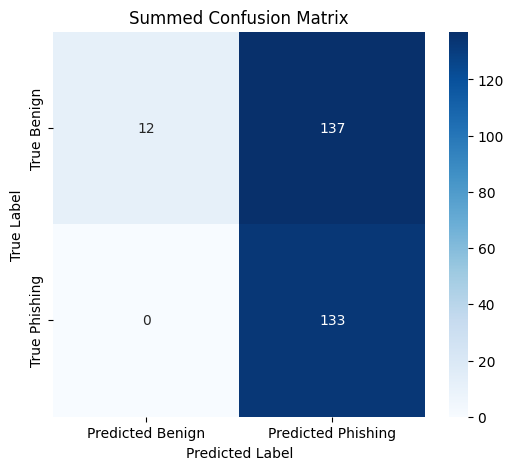


Summed Confusion Matrix Breakdown:
| Metric | Count |
|--------|-------|
| True Positives (TP)  | 133 |
| False Positives (FP) | 137 |
| True Negatives (TN)  | 12 |
| False Negatives (FN) | 0 |

✅ Final Optimized AE Threshold (Mean): 0.405020
✅ Final Optimized Fusion Weight (Mean): 0.10
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
# @title
final_threshold = 0.5
final_fusion_weight = 0.5
if fold_results:
    df_results = pd.DataFrame(fold_results)
    print("\n--- Cross-Validation Results Summary (F1-Scores) ---")
    try:
        from IPython.display import display
        display(df_results[['f1_ae', 'f1_gcn', 'f1_hybrid']])
    except Exception:
        print(df_results[['f1_ae', 'f1_gcn', 'f1_hybrid']].to_string(index=False))

    print("\n--- Average Performance Metrics (± Std Dev) ---")
    hybrid_metrics = ['accuracy_hybrid', 'precision_hybrid', 'recall_hybrid', 'f1_hybrid']
    mean_metrics = df_results[hybrid_metrics].mean()
    std_metrics = df_results[hybrid_metrics].std()
    summary_df = pd.concat([mean_metrics, std_metrics], axis=1)
    summary_df.columns = ['Mean', 'Std Dev']
    summary_df.index = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    try:
        display(summary_df)
    except Exception:
        print(summary_df.to_string())

    if all_confusion_matrices:
        padded_matrices = []
        for cm in all_confusion_matrices:
            if cm.shape == (1, 1):
                padded_cm = np.zeros((2, 2), dtype=int)
                padded_cm[0, 0] = cm[0, 0]
                padded_matrices.append(padded_cm)
            elif cm.shape == (2,2):
                padded_matrices.append(cm)
        if padded_matrices:
            summed_cm = np.sum(padded_matrices, axis=0)
            print("\n--- Summed Confusion Matrix (Across All Folds) ---")
            print(summed_cm)
            plt.figure(figsize=(6,5))
            sns.heatmap(summed_cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Predicted Benign', 'Predicted Phishing'],
                        yticklabels=['True Benign', 'True Phishing'])
            plt.title('Summed Confusion Matrix')
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.show()
            tp, fp, tn, fn = confusion_breakdown(summed_cm)
            print("\nSummed Confusion Matrix Breakdown:")
            print("| Metric | Count |")
            print("|--------|-------|")
            print(f"| True Positives (TP)  | {tp} |")
            print(f"| False Positives (FP) | {fp} |")
            print(f"| True Negatives (TN)  | {tn} |")
            print(f"| False Negatives (FN) | {fn} |")

    final_threshold = float(np.mean(best_thresholds)) if best_thresholds else 0.5
    final_fusion_weight = float(np.mean(best_fusion_weights)) if best_fusion_weights else 0.5
    print(f"\n✅ Final Optimized AE Threshold (Mean): {final_threshold:.6f}")
    print(f"✅ Final Optimized Fusion Weight (Mean): {final_fusion_weight:.2f}")
else:
    print("\nNo CV results to aggregate (likely no user data/graph). Using defaults.")
    final_threshold = 0.5
    final_fusion_weight = 0.5

## 11. Retrain Final Models on All User Data 🎓

In [ ]:
# @title
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, CSVLogger

def show_epoch_table(history, title="AE Training Epochs"):
    hist_df = pd.DataFrame(history.history)
    hist_df.index = hist_df.index + 1
    hist_df.insert(0, "epoch", hist_df.index)
    cols = [c for c in ["epoch","loss","val_loss","lr"] if c in hist_df.columns]
    print(f"\n--- {title} ---")
    try:
        from IPython.display import display
        display(hist_df[cols])
    except Exception:
        print(hist_df[cols].to_string(index=False))
    return hist_df

if len(X_user) > 0:
    # --- Final Scaler on combined benign (public_train_benign + user_benign) ---
    print("\n--- Building Final Scaler (Public Benign Train + User Benign) ---")
    benign_public_train = X_public_train_df[y_public_train == 0].copy()
    benign_user_final = pd.DataFrame(
        X_user[y_user == 0], columns=LEXICAL_FEATURE_COLUMNS
    ) if np.any(y_user == 0) else pd.DataFrame(columns=LEXICAL_FEATURE_COLUMNS)

    benign_combined = pd.concat([benign_public_train, benign_user_final], ignore_index=True)
    if len(benign_combined) == 0:
        print("No benign data available for final scaler; falling back to public-only scaler.")
        final_scaler = scaler
    else:
        final_scaler = RobustScaler().fit(benign_combined)
        print(f"Final scaler fitted on {len(benign_combined)} benign samples.")

    # Save the final scaler (overwrites earlier scaler.pkl so prod stays in sync)
    with open("scaler.pkl", "wb") as f:
        pickle.dump(final_scaler, f)
    print("✅ Saved final scaler.pkl")

    # --- Final Autoencoder Training with MAE, LR scheduling, gradient clipping ---
    print("\n--- Training Final Autoencoder on ALL User Benign (with MAE & LR scheduling) ---")
    X_benign_user_final = X_user[y_user == 0]
    X_benign_user_final_scaled = final_scaler.transform(
        pd.DataFrame(X_benign_user_final, columns=LEXICAL_FEATURE_COLUMNS)
    ) if len(X_benign_user_final) else np.empty((0, len(LEXICAL_FEATURE_COLUMNS)))

    final_ae_model = build_autoencoder(len(LEXICAL_FEATURE_COLUMNS))
    # IMPORTANT: load public pretrain weights first
    final_ae_model.load_weights('pretrained_ae_weights.weights.h5')

    # Optimizer with gradient clipping
    opt = keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0)

    # Switch to MAE for robustness
    final_ae_model.compile(optimizer=opt, loss='mae')

    callbacks = [
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        CSVLogger("final_ae_log.csv", append=False)
    ]

    if len(X_benign_user_final_scaled) > 0:
        history_final = final_ae_model.fit(
            X_benign_user_final_scaled, X_benign_user_final_scaled,
            epochs=60, batch_size=64, verbose=1, validation_split=0.2,
            callbacks=callbacks
        )
        # Print epoch table for final AE
        _final_ae_epochs = show_epoch_table(history_final, title="Final AE Fine-Tune Epochs (MAE)")
        print("Final AE last epoch metrics:", _final_ae_epochs.tail(1).to_dict(orient="records")[0])
        print("\n✅ Final AE model training complete.")
    else:
        print("No benign user data for final AE training. Using pre-trained model.")
        final_ae_model = pretrain_ae_model

    # --- Final GCN Training with per-epoch loss table ---
    print("\n--- Training Final GCN on ALL User Data ---")
    # Use graph built earlier if available
    if 'idx_to_key' in locals() and len(idx_to_key) > 0 and 'x_graph' in locals():
        final_train_mask = torch.zeros(len(idx_to_key), dtype=torch.bool)
        final_node_map = locals().get('post_id_to_node_idx', {})
        final_train_node_indices = [final_node_map.get(pid) for pid in post_ids_user if final_node_map.get(pid) is not None]
        if final_train_node_indices:
            final_train_mask[torch.tensor(final_train_node_indices)] = True

        # Ensure y_nodes exists
        if 'y_nodes' not in locals() or y_nodes.numel() == 0:
            y_nodes = torch.full((len(idx_to_key),), -1, dtype=torch.long)
            for post_id, label in zip(post_ids_user, y_user):
                node_idx = final_node_map.get(post_id)
                if node_idx is not None:
                    y_nodes[node_idx] = int(label)

        final_graph_data = Data(
            x=x_graph, edge_index=edge_index_graph, y=y_nodes, train_mask=final_train_mask
        )

        if final_graph_data.x.numel() > 0 and final_train_mask.sum() > 0:
            final_gcn_model = GCN(num_features=final_graph_data.x.size(1))
            optimizer = optim.Adam(final_gcn_model.parameters(), lr=5e-3, weight_decay=5e-4)

            # Class weights (if both classes present)
            final_train_labels = final_graph_data.y[final_train_mask]
            class_counts = torch.bincount(final_train_labels[final_train_labels >= 0], minlength=2) \
                           if (final_train_labels >= 0).any() else torch.tensor([1,1])
            class_weights = None
            if torch.all(class_counts > 0):
                class_weights = (1.0 / class_counts.float())
                class_weights = class_weights / class_weights.sum()

            gcn_losses = []
            for epoch in range(50):
                final_gcn_model.train()
                optimizer.zero_grad()
                out = final_gcn_model(final_graph_data)
                loss = F.nll_loss(out[final_train_mask], final_graph_data.y[final_train_mask], weight=class_weights)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(final_gcn_model.parameters(), max_norm=2.0)
                optimizer.step()
                gcn_losses.append(float(loss.detach().cpu().item()))

            # Print per-epoch GCN loss table
            gcn_df = pd.DataFrame({"epoch": np.arange(1, len(gcn_losses)+1), "loss": gcn_losses})
            print("\n--- Final GCN Training Epochs ---")
            try:
                from IPython.display import display
                display(gcn_df)
            except Exception:
                print(gcn_df.to_string(index=False))
            print("✅ Final GCN model training complete.")

            # Produce probs for export if you need them later
            final_gcn_model.eval()
            with torch.no_grad():
                final_all_node_logits = final_gcn_model(final_graph_data)
                final_all_node_probs = final_all_node_logits.exp()[:, 1].cpu().numpy()
            print("Generated final GCN probabilities for all nodes.")
        else:
            print("No user data to train final GCN or empty graph.")
            final_gcn_model = None
            final_all_node_probs = np.array([])
    else:
        print("No graph structure available to train final GCN.")
        final_gcn_model = None
        final_all_node_probs = np.array([])
else:
    print("\nNo user data. The final models will be the pre-trained public models.")
    final_ae_model = pretrain_ae_model
    final_gcn_model = None
    final_all_node_probs = np.array([])



--- Building Final Scaler (Public Benign Train + User Benign) ---
Final scaler fitted on 35158 benign samples.
✅ Saved final scaler.pkl

--- Training Final Autoencoder on ALL User Benign (with MAE & LR scheduling) ---
Epoch 1/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - loss: 2.0536 - val_loss: 1.9026 - learning_rate: 5.0000e-04
Epoch 2/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 2.0499 - val_loss: 1.8609 - learning_rate: 5.0000e-04
Epoch 3/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 2.0454 - val_loss: 1.8442 - learning_rate: 5.0000e-04
Epoch 4/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 2.0416 - val_loss: 1.8358 - learning_rate: 5.0000e-04
Epoch 5/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 2.0390 - val_loss: 1.8302 - learning_rate: 5.0000e-04
Epoch 6/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 2.0348 - val_loss: 1.8253 - learning_rate: 5.0000e-04
Epoch 7/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.0344 - val_loss: 1.8211 - learning_rate: 5.0000e-04
Epo

,epoch,loss,val_loss
1,1,2.006511,1.902640
2,2,2.001674,1.860900
3,3,1.997618,1.844235
4,4,1.994624,1.835774
5,5,1.991444,1.830233
6,6,1.988618,1.825348
7,7,1.986489,1.821104
8,8,1.986249,1.817597
9,9,1.982294,1.814632
10,10,1.983959,1.811748


Final AE last epoch metrics: {'epoch': 60, 'loss': 1.9016321897506714, 'val_loss': 1.7411952018737793, 'learning_rate': 0.0005000000237487257}

✅ Final AE model training complete.

--- Training Final GCN on ALL User Data ---

--- Final GCN Training Epochs ---


,epoch,loss
0,1,0.713530
1,2,0.731408
2,3,0.717839
3,4,0.743086
4,5,0.691380
5,6,0.720864
6,7,0.709576
7,8,0.696769
8,9,0.712952
9,10,0.695161


✅ Final GCN model training complete.
Generated final GCN probabilities for all nodes.


## 12. Thesis Performance Evaluation 📝
Compares **Baseline AE** and (if available) **Final Hybrid** on held-out public test set. Prints **Accuracy, Precision, Recall, F1, ROC-AUC**, heatmaps, and confusion breakdowns. Outputs a thesis-ready comparison table.


--- Pre-trained Autoencoder (Baseline) Performance ---
| Metric    | Score    |
| :-------- | :------- |
| Accuracy  | 0.0478   |
| Precision | 1.0000   |
| Recall    | 0.0105   |
| F1-Score  | 0.0207   |
| ROC-AUC   | 0.9783   |


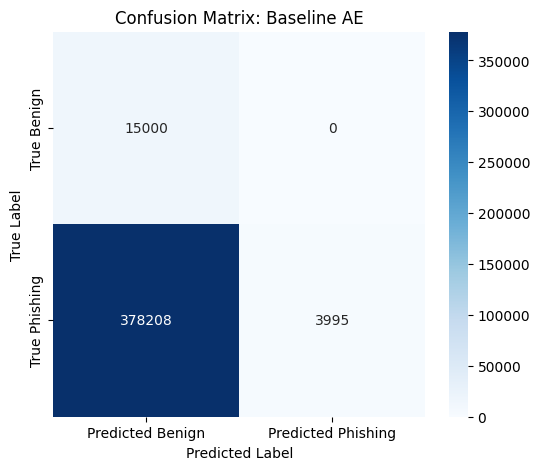


Baseline AE Confusion Breakdown:
| Metric | Count |
|--------|-------|
| True Positives (TP)  | 3995 |
| False Positives (FP) | 0 |
| True Negatives (TN)  | 15000 |
| False Negatives (FN) | 378208 |

--- Final Hybrid Model Performance ---
| Metric    | Score    |
| :-------- | :------- |
| Accuracy  | 0.8753   |
| Precision | 0.9993   |
| Recall    | 0.8710   |
| F1-Score  | 0.9308   |
| ROC-AUC   | 0.9700   |


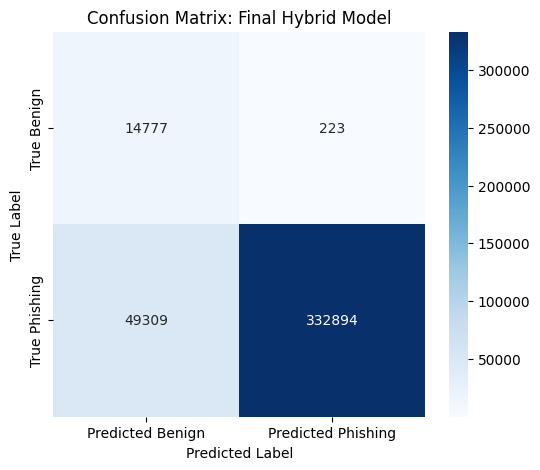


Hybrid Model Confusion Breakdown:
| Metric | Count |
|--------|-------|
| True Positives (TP)  | 332894 |
| False Positives (FP) | 223 |
| True Negatives (TN)  | 14777 |
| False Negatives (FN) | 49309 |

--- Thesis Evaluation Metrics (Baseline AE vs Hybrid) ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline AE,0.047822,1.000000,0.010453,0.020689,0.978325
1,Hybrid Model,0.875298,0.999331,0.870987,0.930755,0.970022


In [ ]:
# @title
def compute_metrics(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc = None
    if y_prob is not None and len(np.unique(y_true)) > 1:
        try:
            roc = roc_auc_score(y_true, y_prob)
        except Exception:
            roc = None
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc, 'cm': cm}

def print_metrics_table(name, m):
    print(f"\n--- {name} Performance ---")
    print("| Metric    | Score    |")
    print("| :-------- | :------- |")
    print(f"| Accuracy  | {m['accuracy']:.4f}   |")
    print(f"| Precision | {m['precision']:.4f}   |")
    print(f"| Recall    | {m['recall']:.4f}   |")
    print(f"| F1-Score  | {m['f1']:.4f}   |")
    if m['roc_auc'] is not None:
        print(f"| ROC-AUC   | {m['roc_auc']:.4f}   |")

def plot_cm(cm, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Benign', 'Predicted Phishing'], yticklabels=['True Benign', 'True Phishing'])
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Baseline AE (public test set)
X_public_test_scaled = scaler.transform(X_public_test_df)
baseline_reconstructed = pretrain_ae_model.predict(X_public_test_scaled, verbose=0)
baseline_errors = np.mean(np.square(X_public_test_scaled - baseline_reconstructed), axis=1)
X_benign_public_train_scaled = scaler.transform(X_public_train_df)
baseline_train_reconstructed = pretrain_ae_model.predict(X_benign_public_train_scaled, verbose=0)
baseline_train_errors = np.mean(np.square(X_benign_public_train_scaled - baseline_train_reconstructed), axis=1)
baseline_threshold = np.percentile(baseline_train_errors, 99)
baseline_preds = (baseline_errors > baseline_threshold).astype(int)
baseline_metrics = compute_metrics(y_public_test, baseline_preds, y_prob=baseline_errors)
print_metrics_table("Pre-trained Autoencoder (Baseline)", baseline_metrics)
plot_cm(baseline_metrics['cm'], 'Confusion Matrix: Baseline AE')
print_confusion_table(baseline_metrics['cm'], title="Baseline AE Confusion Breakdown")

# Final Hybrid (if user data/graph existed)
hybrid_metrics = None
if 'final_ae_model' in locals() and final_ae_model is not None and isinstance(final_threshold, float):
    final_reconstructed = final_ae_model.predict(X_public_test_scaled, verbose=0)
    final_ae_errors = np.mean(np.square(X_public_test_scaled - final_reconstructed), axis=1)
    final_ae_probs = final_ae_errors / (final_threshold + 1e-9)
    final_gcn_probs = np.full_like(final_ae_probs, 0.5)  # neutral for public test posts
    final_fused_scores = final_fusion_weight * np.minimum(final_ae_probs, 1.0) + (1 - final_fusion_weight) * final_gcn_probs
    final_hybrid_preds = (final_fused_scores > 0.5).astype(int)
    hybrid_metrics = compute_metrics(y_public_test, final_hybrid_preds, y_prob=final_fused_scores)
    print_metrics_table("Final Hybrid Model", hybrid_metrics)
    plot_cm(hybrid_metrics['cm'], 'Confusion Matrix: Final Hybrid Model')
    print_confusion_table(hybrid_metrics['cm'], title="Hybrid Model Confusion Breakdown")
else:
    print("\nHybrid evaluation skipped (final AE/graph not available); only Baseline AE reported.")

# Thesis-ready comparison table
rows = [{
    'Model': 'Baseline AE',
    'Accuracy': baseline_metrics['accuracy'],
    'Precision': baseline_metrics['precision'],
    'Recall': baseline_metrics['recall'],
    'F1-Score': baseline_metrics['f1'],
    'ROC-AUC': baseline_metrics['roc_auc'] if baseline_metrics['roc_auc'] is not None else np.nan
}]
if hybrid_metrics is not None:
    rows.append({
        'Model': 'Hybrid Model',
        'Accuracy': hybrid_metrics['accuracy'],
        'Precision': hybrid_metrics['precision'],
        'Recall': hybrid_metrics['recall'],
        'F1-Score': hybrid_metrics['f1'],
        'ROC-AUC': hybrid_metrics['roc_auc'] if hybrid_metrics['roc_auc'] is not None else np.nan
    })
thesis_table = pd.DataFrame(rows)[['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']]
print("\n--- Thesis Evaluation Metrics (Baseline AE vs Hybrid) ---")
try:
    from IPython.display import display
    display(thesis_table)
except Exception:
    print(thesis_table.to_string(index=False))

## 13. Export Artifacts for Application 📦

In [ ]:
# @title
print("\n--- Exporting Final Artifacts ---")
final_ae_model_to_save = locals().get('final_ae_model', pretrain_ae_model)
final_ae_model_to_save.save("phishing_autoencoder_model.keras")
print("Saved phishing_autoencoder_model.keras")
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Saved scaler.pkl")
with open("autoencoder_threshold.txt", "w") as f:
    f.write(str(final_threshold))
print("Saved autoencoder_threshold.txt")
if locals().get('final_gcn_model', None) is not None:
    torch.save(final_gcn_model.state_dict(), "gnn_model.pth")
    print("Saved gnn_model.pth")
    if 'post_id_to_node_idx' in locals():
        with open("post_node_map.json", "w") as f:
            json.dump(post_id_to_node_idx, f)
        print("Saved post_node_map.json")
    if 'final_all_node_probs' in locals() and isinstance(final_all_node_probs, np.ndarray) and final_all_node_probs.size > 0:
        np.save("gnn_probs.npy", final_all_node_probs)
        print("Saved gnn_probs.npy")
fusion_config = {'ae_threshold': float(final_threshold), 'fusion_weight_ae': float(final_fusion_weight)}
with open("fusion_config.json", "w") as f:
    json.dump(fusion_config, f)
print("Saved fusion_config.json")
print("\n✅ All artifacts exported successfully.")


--- Exporting Final Artifacts ---
Saved phishing_autoencoder_model.keras
Saved scaler.pkl
Saved autoencoder_threshold.txt
Saved gnn_model.pth
Saved post_node_map.json
Saved gnn_probs.npy
Saved fusion_config.json

✅ All artifacts exported successfully.


## 14. Download Artifacts ⬇️ (Colab)

In [ ]:
# @title
if IN_COLAB and files is not None:
    print("Preparing to download artifacts...")
    artifacts_to_download = [
        "phishing_autoencoder_model.keras",
        "scaler.pkl",
        "autoencoder_threshold.txt",
        "gnn_model.pth",
        "post_node_map.json",
        "fusion_config.json",
        "gnn_probs.npy"
    ]
    for artifact in artifacts_to_download:
        if os.path.exists(artifact):
            print(f"Downloading {artifact}...")
            try:
                files.download(artifact)
            except Exception:
                print(f"Please download manually: {artifact}")
        else:
            print(f"Skipping {artifact} as it was not found.")
else:
    print("Colab download helper skipped (not in Colab). Files are saved in working directory.")

Preparing to download artifacts...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>